# Sanskrit -> English NMT (single notebook: trains OR evaluates)

This notebook auto-detects whether a trained checkpoint already exists next
to it (`best_model.pt`, `sa_vocab.json`, `en_vocab.json`, `model_config.json`):

- **Not found** -> it trains from scratch on the provided train/dev data and
  saves those 4 files.
- **Found** -> it skips training entirely, loads the checkpoint, and goes
  straight to inference/evaluation. This is the path that runs during
  in-class evaluation on the private test set.

To force retraining even if a checkpoint exists, set `FORCE_RETRAIN = True`
in the config cell below.

**Pretrained models/methods disclosed:** the translation model is a custom,
from-scratch BiLSTM encoder + additive attention + LSTM decoder (no
pretrained MT model). `bert-score` (metric only, not translation) uses a
pretrained RoBERTa/BERT backbone under the hood.

In [1]:
!pip install bert-score
!pip install nltk
!pip install tqdm
!pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.6 MB/s eta 0:00:00


In [2]:
import random
import time
import math
import os
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import nltk
nltk.download("punkt")

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from nltk.translate.bleu_score import corpus_bleu
from bert_score import score as bertscore_fn

from tqdm import tqdm


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


## Config

Change the paths below when a new (e.g. private) test set is handed out.
`TEST_EN_PATH = None` means no gold reference is available -- the notebook
will still produce `submission.csv`, just without BLEU/BERTScore.

In [5]:
TRAIN_SA_PATH = "train_sa_10000.csv"
TRAIN_EN_PATH = "train_en_10000.csv"
DEV_SA_PATH   = "dev_sa_1000.csv"
DEV_EN_PATH   = "dev_en_1000.csv"
TEST_SA_PATH  = "test_sa_1000.csv"
TEST_EN_PATH  = "test_en_1000.csv"   # set to None if no reference is provided

FORCE_RETRAIN = False  # set True to retrain even if a checkpoint already exists

ARTIFACT_FILES = ["best_model.pt", "sa_vocab.json", "en_vocab.json", "model_config.json"]
CHECKPOINT_EXISTS = all(os.path.exists(p) for p in ARTIFACT_FILES)
TRAIN_MODE = FORCE_RETRAIN or (not CHECKPOINT_EXISTS)

print("Checkpoint files found:", CHECKPOINT_EXISTS)
print("TRAIN_MODE:", TRAIN_MODE)


Checkpoint files found: False
TRAIN_MODE: True


## Load data

In [7]:
train_sa = pd.read_csv("train_sa_10000.csv")

train_en = pd.read_csv("train_en_10000.csv")

dev_sa = pd.read_csv("dev_sa_1000.csv")

dev_en = pd.read_csv("dev_en_1000.csv")

test_sa = pd.read_csv("test_sa_1000.csv")

test_en = pd.read_csv("test_en_1000.csv")

has_test_reference = TEST_EN_PATH is not None and os.path.exists(TEST_EN_PATH)
if has_test_reference:
    test_en = pd.read_csv(TEST_EN_PATH)

train = pd.merge(train_sa, train_en, on="Source_id").dropna()
dev = pd.merge(dev_sa, dev_en, on="Source_id").dropna()

if has_test_reference:
    test = pd.merge(test_sa, test_en, on="Source_id").dropna()
else:
    test = test_sa.dropna().copy()

print(train.shape, dev.shape, test.shape)
print("Test set has gold reference:", has_test_reference)


(10000, 3) (1000, 3) (1000, 3)
Test set has gold reference: True


**Preprocessing + Vocabulary**

In [8]:
def tokenize(text):
    return text.strip().split()


def sentence_to_ids(sentence, vocab):
    ids = []
    for token in tokenize(sentence):
        ids.append(vocab.get(token, vocab["<UNK>"]))
    return ids


def pad_sequence(seq, max_len):
    if len(seq) < max_len:
        seq = seq + [0] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq


PAD, UNK, SOS, EOS = "<PAD>", "<UNK>", "<SOS>", "<EOS>"

train["Sentence_en"] = train["Sentence_en"].apply(lambda x: f"{SOS} " + str(x) + f" {EOS}")
dev["Sentence_en"] = dev["Sentence_en"].apply(lambda x: f"{SOS} " + str(x) + f" {EOS}")
if has_test_reference:
    test["Sentence_en"] = test["Sentence_en"].apply(lambda x: f"{SOS} " + str(x) + f" {EOS}")


In [9]:
if TRAIN_MODE:
    # Build vocab from scratch, from the training data only
    MIN_FREQ = 1

    sa_counter = Counter()
    for sentence in train["Sentence_sa"]:
        sa_counter.update(tokenize(sentence))

    en_counter = Counter()
    for sentence in train["Sentence_en"]:
        en_counter.update(tokenize(sentence))

    sa_vocab = {PAD: 0, UNK: 1}
    for word, freq in sa_counter.items():
        if freq >= MIN_FREQ:
            sa_vocab[word] = len(sa_vocab)

    en_vocab = {PAD: 0, UNK: 1, SOS: 2, EOS: 3}
    for word, freq in en_counter.items():
        if freq >= MIN_FREQ and word not in en_vocab:
            en_vocab[word] = len(en_vocab)

    MAX_SRC_LEN = max(len(tokenize(x)) for x in train["Sentence_sa"])
    MAX_TGT_LEN = max(len(tokenize(x)) for x in train["Sentence_en"])

else:
    # Load the vocab that the checkpoint was trained with -- do NOT rebuild,
    # it must match best_model.pt exactly
    with open("sa_vocab.json", "r", encoding="utf-8") as f:
        sa_vocab = json.load(f)
    with open("en_vocab.json", "r", encoding="utf-8") as f:
        en_vocab = json.load(f)

    MAX_SRC_LEN = max(len(tokenize(x)) for x in train["Sentence_sa"])
    MAX_TGT_LEN = max(len(tokenize(x)) for x in train["Sentence_en"])

idx2sa = {v: k for k, v in sa_vocab.items()}
idx2en = {v: k for k, v in en_vocab.items()}

print("Sanskrit vocab size:", len(sa_vocab))
print("English vocab size :", len(en_vocab))


Sanskrit vocab size: 33276
English vocab size : 19552


In [10]:
class TranslationDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        src = pad_sequence(sentence_to_ids(row["Sentence_sa"], sa_vocab), MAX_SRC_LEN)
        tgt = pad_sequence(sentence_to_ids(row["Sentence_en"], en_vocab), MAX_TGT_LEN)
        return torch.tensor(src), torch.tensor(tgt)


BATCH_SIZE = 64

train_dataset = TranslationDataset(train)
dev_dataset = TranslationDataset(dev)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)


**Encoder + Attention + Decoder + Seq2Seq**

In [11]:
if TRAIN_MODE:
    ENC_EMB_DIM, DEC_EMB_DIM = 256, 256
    HIDDEN_DIM = 512
    NUM_LAYERS = 2
    ENC_DROPOUT, DEC_DROPOUT = 0.2, 0.2
    INPUT_DIM = len(sa_vocab)
    OUTPUT_DIM = len(en_vocab)
else:
    with open("model_config.json", "r", encoding="utf-8") as f:
        cfg = json.load(f)
    ENC_EMB_DIM = cfg["ENC_EMB_DIM"]
    DEC_EMB_DIM = cfg["DEC_EMB_DIM"]
    HIDDEN_DIM = cfg["HIDDEN_DIM"]
    NUM_LAYERS = cfg["NUM_LAYERS"]
    ENC_DROPOUT = cfg["ENC_DROPOUT"]
    DEC_DROPOUT = cfg["DEC_DROPOUT"]
    INPUT_DIM = cfg["INPUT_DIM"]
    OUTPUT_DIM = cfg["OUTPUT_DIM"]

print(ENC_EMB_DIM, DEC_EMB_DIM, HIDDEN_DIM, NUM_LAYERS, INPUT_DIM, OUTPUT_DIM)


256 256 512 2 33276 19552


In [12]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            emb_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell


In [13]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 3, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[1]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=1)


In [14]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, num_layers, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            emb_dim + hidden_dim * 2, hidden_dim,
            num_layers=num_layers, batch_first=True, dropout=dropout
        )
        self.fc = nn.Linear(hidden_dim * 3, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, cell, encoder_outputs):
        input = input.unsqueeze(1)
        embedded = self.dropout(self.embedding(input))
        hidden_last = hidden[-1]
        attention = self.attention(hidden_last, encoder_outputs).unsqueeze(1)
        context = torch.bmm(attention, encoder_outputs)
        lstm_input = torch.cat((embedded, context), dim=2)
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.fc(torch.cat((output.squeeze(1), context.squeeze(1)), dim=1))
        return prediction, hidden, cell


In [15]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device, hidden_dim, num_layers):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)
        encoder_outputs, hidden, cell = self.encoder(src)

        hidden = hidden.view(self.num_layers, 2, batch_size, self.hidden_dim).sum(dim=1)
        cell = cell.view(self.num_layers, 2, batch_size, self.hidden_dim).sum(dim=1)

        input = tgt[:, 0]
        for t in range(1, tgt_len):
            output, hidden, cell = self.decoder(input, hidden, cell, encoder_outputs)
            outputs[:, t] = output
            top1 = output.argmax(1)
            teacher_force = random.random() < teacher_forcing_ratio
            input = tgt[:, t] if teacher_force else top1

        return outputs


In [16]:
attention = Attention(HIDDEN_DIM)
encoder = Encoder(INPUT_DIM, ENC_EMB_DIM, HIDDEN_DIM, NUM_LAYERS, ENC_DROPOUT)
decoder = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DEC_DROPOUT, attention)

model = Seq2Seq(encoder, decoder, device, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS).to(device)

total_params = sum(p.numel() for p in model.parameters())
print("Total trainable parameters:", total_params)


Total trainable parameters: 59591776


## Train (skipped automatically if a checkpoint already exists)

In [17]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=0.001)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    epoch_loss = 0
    for src, tgt in tqdm(loader):
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        output = model(src, tgt)
        output = output[:, 1:].reshape(-1, OUTPUT_DIM)
        tgt_flat = tgt[:, 1:].reshape(-1)
        loss = criterion(output, tgt_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)


def evaluate_loss(model, loader, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            output = model(src, tgt, teacher_forcing_ratio=0)
            output = output[:, 1:].reshape(-1, OUTPUT_DIM)
            tgt_flat = tgt[:, 1:].reshape(-1)
            loss = criterion(output, tgt_flat)
            epoch_loss += loss.item()
    return epoch_loss / len(loader)



Epoch 1/15


100%|██████████| 157/157 [06:25<00:00,  2.46s/it]


Train Loss : 7.2781
Valid Loss : 7.0442
Best Model Saved

Epoch 2/15


100%|██████████| 157/157 [06:30<00:00,  2.49s/it]


Train Loss : 6.7293
Valid Loss : 7.0554

Epoch 3/15


...

Train Loss : 3.5295
Valid Loss : 7.5129

Epoch 14/15


100%|██████████| 157/157 [06:31<00:00,  2.50s/it]


Train Loss : 3.2539
Valid Loss : 7.7089

Epoch 15/15


100%|██████████| 157/157 [06:31<00:00,  2.49s/it]


Train Loss : 2.9850
Valid Loss : 7.7643


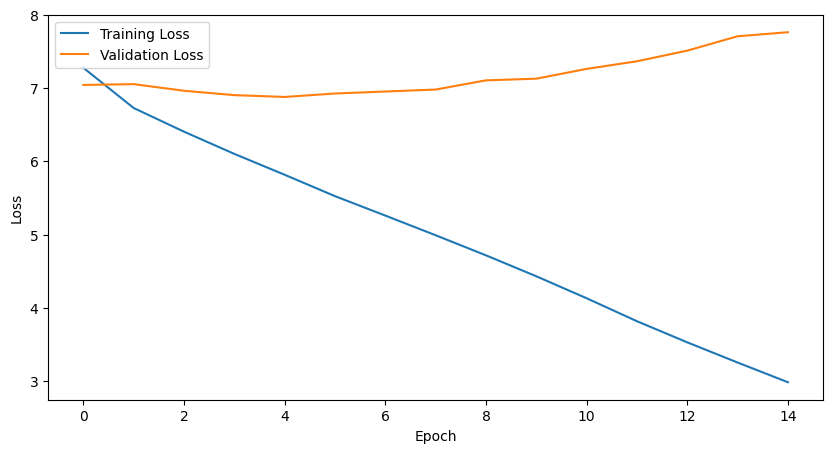

Training complete. Best validation loss: 6.880372256040573
Saved best_model.pt, sa_vocab.json, en_vocab.json, model_config.json


In [18]:
if TRAIN_MODE:
    N_EPOCHS = 15
    best_valid_loss = float("inf")
    train_losses, valid_losses = [], []

    for epoch in range(N_EPOCHS):
        print(f"\nEpoch {epoch+1}/{N_EPOCHS}")
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        valid_loss = evaluate_loss(model, dev_loader, criterion)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Valid Loss : {valid_loss:.4f}")

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), "best_model.pt")
            print("Best Model Saved")

    model.load_state_dict(torch.load("best_model.pt"))

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Training Loss")
    plt.plot(valid_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Save vocab + config so future runs (or the evaluation-only path above)
    # can skip straight to inference without retraining
    with open("sa_vocab.json", "w", encoding="utf-8") as f:
        json.dump(sa_vocab, f, ensure_ascii=False)
    with open("en_vocab.json", "w", encoding="utf-8") as f:
        json.dump(en_vocab, f, ensure_ascii=False)

    model_config = {
        "ENC_EMB_DIM": ENC_EMB_DIM, "DEC_EMB_DIM": DEC_EMB_DIM,
        "HIDDEN_DIM": HIDDEN_DIM, "NUM_LAYERS": NUM_LAYERS,
        "ENC_DROPOUT": ENC_DROPOUT, "DEC_DROPOUT": DEC_DROPOUT,
        "INPUT_DIM": INPUT_DIM, "OUTPUT_DIM": OUTPUT_DIM,
    }
    with open("model_config.json", "w", encoding="utf-8") as f:
        json.dump(model_config, f)

    print("Training complete. Best validation loss:", best_valid_loss)
    print("Saved best_model.pt, sa_vocab.json, en_vocab.json, model_config.json")

else:
    model.load_state_dict(torch.load("best_model.pt", map_location=device))
    model.eval()
    print("Loaded existing checkpoint -- skipped training.")


## Inference: greedy and beam search decoding

In [24]:
def translate_sentence(sentence, model, sa_vocab, en_vocab, idx2en, device, max_len=50):
    model.eval()
    src = torch.LongTensor(sentence_to_ids(sentence, sa_vocab)).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src)
        hidden = hidden.view(model.num_layers, 2, 1, model.hidden_dim).sum(dim=1)
        cell = cell.view(model.num_layers, 2, 1, model.hidden_dim).sum(dim=1)

    input_token = torch.tensor([en_vocab["<SOS>"]], device=device)
    prediction_words = []

    for _ in range(max_len):
        with torch.no_grad():
            output, hidden, cell = model.decoder(input_token, hidden, cell, encoder_outputs)
        best_token = output.argmax(1).item()
        if best_token == en_vocab["<EOS>"]:
            break
        prediction_words.append(idx2en[best_token])
        input_token = torch.tensor([best_token], device=device)

    return " ".join(prediction_words)


def translate_sentence_beam(
    sentence, model, sa_vocab, en_vocab, idx2en, device,
    beam_width=5, max_len=50, length_penalty=0.7
):
    model.eval()
    src_ids = sentence_to_ids(sentence, sa_vocab)
    src = torch.LongTensor(src_ids).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src)
        hidden = hidden.view(model.num_layers, 2, 1, model.hidden_dim).sum(dim=1)
        cell = cell.view(model.num_layers, 2, 1, model.hidden_dim).sum(dim=1)

    sos_idx, eos_idx = en_vocab["<SOS>"], en_vocab["<EOS>"]
    beams = [([sos_idx], 0.0, hidden, cell, False)]
    completed = []

    for _ in range(max_len):
        new_beams = []
        for tokens, log_prob, h, c, finished in beams:
            if finished:
                completed.append((tokens, log_prob))
                continue
            input_token = torch.tensor([tokens[-1]], device=device)
            with torch.no_grad():
                output, h_new, c_new = model.decoder(input_token, h, c, encoder_outputs)
            log_probs = torch.log_softmax(output, dim=1).squeeze(0)
            top_log_probs, top_idx = log_probs.topk(beam_width)
            for lp, idx in zip(top_log_probs.tolist(), top_idx.tolist()):
                new_tokens = tokens + [idx]
                new_finished = (idx == eos_idx)
                new_beams.append((new_tokens, log_prob + lp, h_new, c_new, new_finished))

        if not new_beams:
            break
        new_beams.sort(key=lambda x: x[1], reverse=True)
        beams = new_beams[:beam_width]
        if all(b[4] for b in beams):
            completed.extend([(b[0], b[1]) for b in beams])
            break

    if not completed:
        completed = [(b[0], b[1]) for b in beams]

    def score_fn(item):
        tokens, log_prob = item
        length = max(len(tokens) - 1, 1)
        return log_prob / (length ** length_penalty)

    best_tokens, _ = max(completed, key=score_fn)
    words = [idx2en[t] for t in best_tokens[1:] if t not in (sos_idx, eos_idx)]
    return " ".join(words)


## Full evaluation: BLEU, BERTScore, timing, param count (dev + test)

In [25]:
!pip install --upgrade bert-score transformers

In [ ]:
def evaluate_full(df, split_name, decode_fn, **decode_kwargs):
    references, predictions = [], []
    start = time.time()
    for _, row in df.iterrows():
        pred = decode_fn(row["Sentence_sa"], model, sa_vocab, en_vocab, idx2en, device, **decode_kwargs)
        predictions.append(pred.split())
        ref_clean = row["Sentence_en"].replace("<SOS>", "").replace("<EOS>", "").strip()
        references.append([ref_clean.split()])
    end = time.time()

    bleu = corpus_bleu(references, predictions)
    pred_sentences = [" ".join(p) for p in predictions]
    ref_sentences = [" ".join(r[0]) for r in references]
    P, R, F1 = bertscore_fn(pred_sentences, ref_sentences, lang="en", rescale_with_baseline=True)

    inference_time = end - start
    print(f"--- {split_name} (beam_width={decode_kwargs.get('beam_width', 'greedy')}) ---")
    print(f"BLEU              : {bleu:.4f}")
    print(f"BERTScore F1      : {F1.mean().item():.4f}")
    print(f"Inference time    : {inference_time:.2f}s for {len(df)} sentences")
    print()

    return {"bleu": bleu, "bertscore_f1": F1.mean().item(),
            "inference_time_sec": inference_time, "n_sentences": len(df)}


results_summary = {"total_params": total_params}

results_summary["dev"] = evaluate_full(dev, "DEV", translate_sentence_beam, beam_width=5)

if has_test_reference:
    results_summary["test"] = evaluate_full(test, "TEST", translate_sentence_beam, beam_width=5)
else:
    print("No test reference available -- skipping test-set BLEU/BERTScore (submission.csv will still be produced below).")

with open("results_summary.json", "w") as f:
    json.dump(results_summary, f, indent=2)

print("Saved results_summary.json")


## Generate submission.csv (always runs, with or without a reference)

In [ ]:
start = time.time()

submission = pd.DataFrame()
submission["Source_id"] = test_sa["Source_id"]
submission["Sentence_en"] = [
    translate_sentence_beam(s, model, sa_vocab, en_vocab, idx2en, device, beam_width=5)
    for s in test_sa["Sentence_sa"]
]

end = time.time()
print(f"Generated {len(submission)} translations with beam search in {end-start:.2f}s")

submission.to_csv("submission.csv", index=False, encoding="utf-8")
submission.head()


## Qualitative examples (for the report)

In [ ]:
for i in range(10):
    print("=" * 80)
    print("Sanskrit")
    print(dev.iloc[i]["Sentence_sa"])
    print()
    print("Reference")
    print(dev.iloc[i]["Sentence_en"])
    print()
    print("Prediction (beam search)")
    print(translate_sentence_beam(dev.iloc[i]["Sentence_sa"], model, sa_vocab, en_vocab, idx2en, device, beam_width=5))
    print()
